### Tissera Ana Paula - `Notebook TP4`

In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Imports

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
import cupy as cp

device_id = cp.cuda.Device().id
device_name = cp.cuda.runtime.getDeviceProperties(device_id)['name']

print(f"Usando GPU {device_id}: {device_name}")

Usando GPU 0: b'NVIDIA GeForce RTX 3050 Laptop GPU'


In [39]:
SEED = 42

## `1.` **Clustering de datos**

##### Cargar los datos

In [40]:
clustering_path = "data/clustering.csv"
clustering_df = pd.read_csv(clustering_path)

##### Visualización de ejemplo

In [41]:
clustering_df.sample(5, random_state=SEED)

,Unnamed: 0,A,B
84,84,822368,648690
2470,2470,954037,754046
2804,2804,640123,716370
4987,4987,772586,123935
4924,4924,598444,128607


In [42]:
clustering_df = clustering_df.drop(clustering_df.columns[0], axis=1)

In [43]:
clustering_df.sample(5, random_state=SEED)

,A,B
84,822368,648690
2470,954037,754046
2804,640123,716370
4987,772586,123935
4924,598444,128607


In [44]:
X_cpu = clustering_df.values
X = cp.array(X_cpu)  # pasar a GPU
X = cp.array(clustering_df.values)

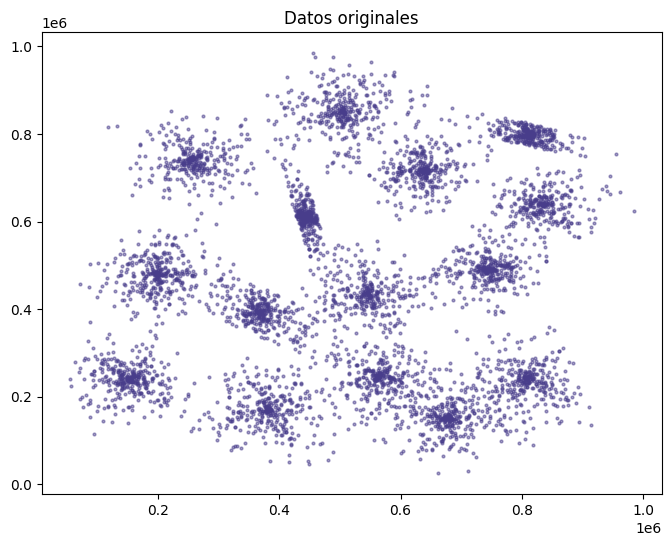

In [45]:
plt.figure(figsize=(8, 6))
plt.plot(X_cpu[:, 0], X_cpu[:, 1], "o", markersize=2, alpha=0.5, color = "darkslateblue")
plt.title("Datos originales")
plt.show()

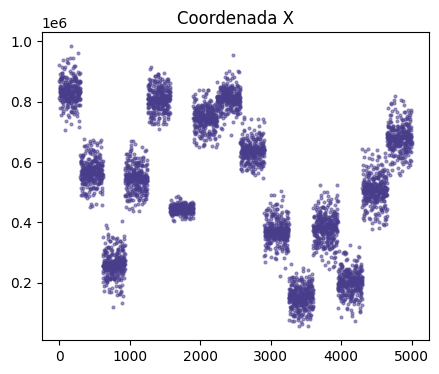

In [46]:
plt.figure(figsize=(5, 4))
plt.plot(X_cpu[:, 0], "o", markersize=2, alpha=0.5, color = "darkslateblue")
plt.title("Coordenada X")
plt.show()

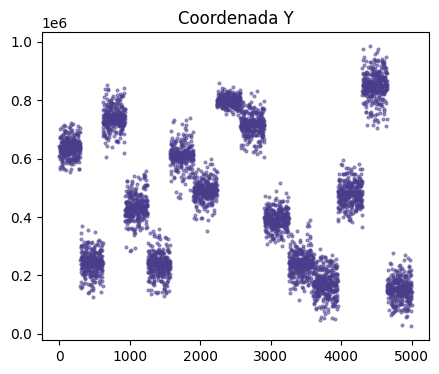

In [47]:
plt.figure(figsize=(5, 4))
plt.plot(X_cpu[:, 1], "o", markersize=2, alpha=0.5, color = "darkslateblue")
plt.title("Coordenada Y")
plt.show()

### `a.` **K-Means** con ganancias decrecientes para determinar K

In [48]:
from src.models import KMeans
from src.utils import find_elbow

##### $L$ vs. $K$

In [ ]:
Ks = list(range(1, 20))
Ls = []
for K in Ks:
    km = KMeans(n_clusters=K, init="k-means++", n_init=10,
                max_iter=300, tol=1e-4, random_state=42)
    km.fit(X)
    print(f"K = {K:2d} → Inercia = {km.distortion_:.2f}")
    Ls.append(km.distortion_)

elbow_idx, distances = find_elbow(Ks, Ls, alpha = 0.0177)
bestK = Ks[elbow_idx]
bestL = Ls[elbow_idx]
print(f"\nEl mejor número de clusters según el método del codo es K = {bestK}")


K =  1 → Inercia = 516864302744182.00
K =  2 → Inercia = 289934063974210.00
K =  3 → Inercia = 182617259354599.00
K =  4 → Inercia = 119781237770822.00
K =  5 → Inercia = 97158902693967.00
K =  6 → Inercia = 79352490290900.00
K =  7 → Inercia = 66442291574055.00
K =  8 → Inercia = 56002180572199.00
K =  9 → Inercia = 45039384213855.00
K = 10 → Inercia = 39506532259043.00
K = 11 → Inercia = 31693774488119.00
K = 12 → Inercia = 24877328816656.00
K = 13 → Inercia = 20833857832204.00
K = 14 → Inercia = 16848986287901.00
K = 15 → Inercia = 13279024047994.00
K = 16 → Inercia = 12878514745437.00
K = 17 → Inercia = 12533515534453.00
K = 18 → Inercia = 12190859497060.00
K = 19 → Inercia = 11827965038787.00

El mejor número de clusters según el método del codo es K = 15


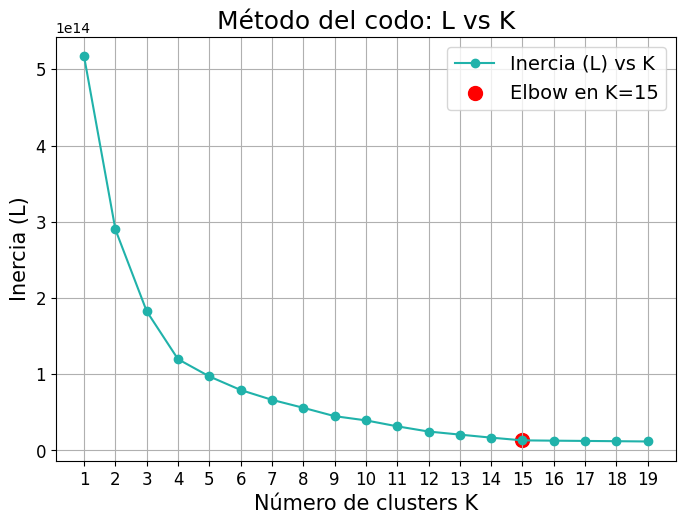

In [ ]:
from src.plot import plot_lvsk
    
plot_lvsk(Ks, Ls, bestK, bestL)

In [51]:
km = KMeans(n_clusters=bestK, init="k-means++", n_init=10,
            max_iter=300, tol=1e-4, random_state=42)
labels = km.fit_predict(X)

print(f"Inercia final: {km.distortion_:.2f}")
print(f"Iteraciones en la mejor ejecución: {km.n_iter_}")

Inercia final: 13279024047994.00
Iteraciones en la mejor ejecución: 16


##### Gráfico del conjunto $x_i$

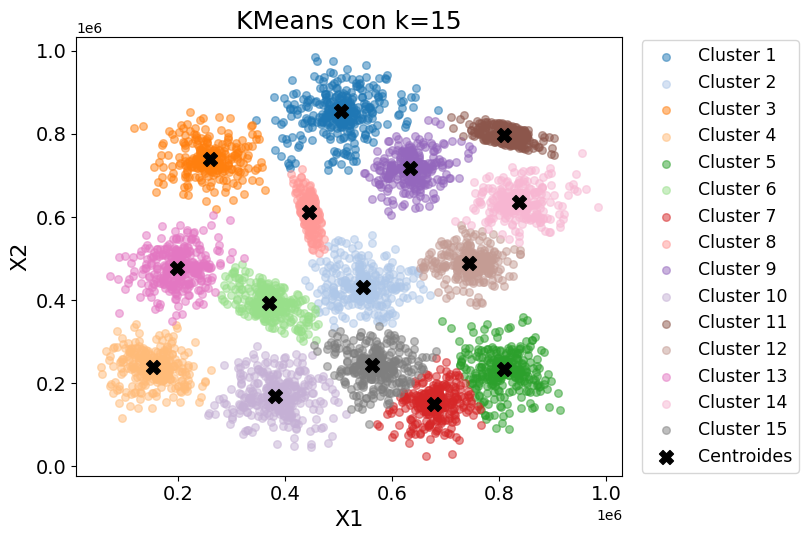

In [ ]:
from src.plot import plot_kmeans

plot_kmeans(km, X, labels)

Ver medias de K-means

In [ ]:
centroides = np.vstack([km.cluster_centers_[k].get() for k in range(bestK)])
df_means = pd.DataFrame(centroides, columns=["X1", "X2"])
df_means.index = [f"Cluster {i+1}" for i in range(bestK)]

print(df_means)

                X1      X2
Cluster 1   503665  854338
Cluster 2   371101  392427
Cluster 3   380160  169091
Cluster 4   545950  432863
Cluster 5   562468  243230
Cluster 6   809538  797406
Cluster 7   677971  150751
Cluster 8   742741  489417
Cluster 9   258855  740048
Cluster 10  808125  234833
Cluster 11  633300  717099
Cluster 12  444512  611892
Cluster 13  152590  239488
Cluster 14  199455  478149
Cluster 15  836493  636549


### `b.`  Gaussian Mixture Model (**GMM**)

##### inicialización de GMM con una corrida de K-means

In [ ]:
from src.models import GMM

Inicializar parámetros con K-Means

In [ ]:
km = KMeans(n_clusters=bestK, init="k-means++", n_init=10,
            max_iter=300, tol=1e-4, random_state=42)

labels_k = km.fit_predict(X)
means0 = km.cluster_centers_
counts = cp.bincount(labels_k, minlength=bestK).astype(cp.float64)
weights0 = counts / X.shape[0]
D = X.shape[1]
covs0 = cp.zeros((bestK, D, D), dtype=cp.float64)
for k in range(bestK):
    Xk = X[labels_k == k].astype(cp.float64)
    diff = Xk - means0[k]
    covs0[k] = (diff.T @ diff) / Xk.shape[0] + cp.eye(D, dtype=cp.float64)*1e-6

Ajustar GMM

In [ ]:
init_params = {'means': means0, 'weights': weights0, 'covs': covs0}

gmm = GMM(n_components=bestK, tol=1e-4, max_iter=100,
            reg_covar=1e-6, random_state=42, init_params=init_params)
labels = gmm.fit_predict(X)
print(f"GMM final con K={bestK}: LL={gmm.log_likelihood_:.2f}, iter={gmm.n_iter_}")

GMM final con K=15: LL=-131948.36, iter=100


##### Visualización de los datos

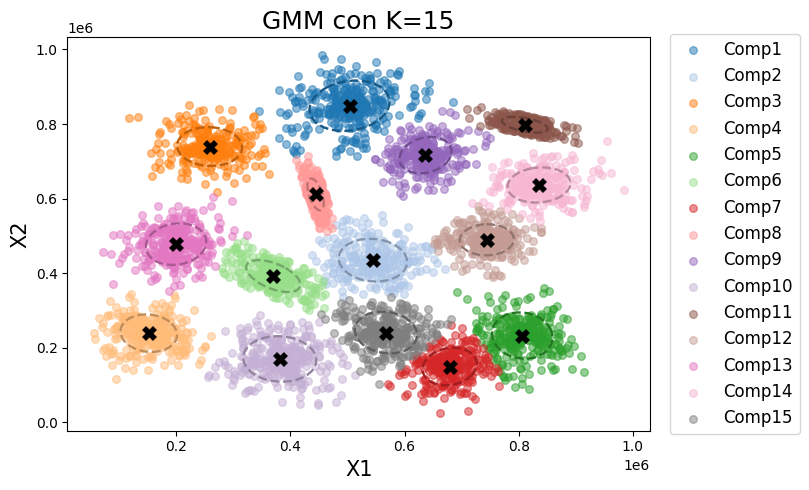

In [ ]:
from src.plot import plot_GMM
    
plot_GMM(gmm, X, labels, bestK)

Medias de GMM

In [ ]:
means_GMM = np.vstack([gmm.means_[k].get() for k in range(bestK)])
df_means = pd.DataFrame(means_GMM, columns=["X1", "X2"])
df_means.index = [f"Cluster {i+1}" for i in range(bestK)]

print(df_means)

                       X1             X2
Cluster 1   503639.445011  848998.565730
Cluster 2   370046.810416  392366.505896
Cluster 3   381361.066834  170139.184861
Cluster 4   544685.622839  435067.992863
Cluster 5   567524.731561  240980.837211
Cluster 6   810811.488999  798129.772216
Cluster 7   679011.244358  149685.759591
Cluster 8   744174.637727  489608.698710
Cluster 9   258526.838558  739614.490923
Cluster 10  806234.677708  232888.813934
Cluster 11  636710.032028  716633.560039
Cluster 12  444257.555581  611222.244208
Cluster 13  151947.169780  239269.053636
Cluster 14  199769.124974  478031.611482
Cluster 15  835491.527516  636631.840717


### `c.`  **DBSCAN**

In [61]:
from src.models import DBSCAN

##### Variación de los parámetros ε (radio de la vecindad) y $K$ (mínimo número de puntos en una zona densa)

In [ ]:
X_cpu = clustering_df.values.astype(float)
X = cp.array(X_cpu)

mean = X.mean(axis=0)
std  = X.std(axis=0)
Xn = (X - mean) / std

eps_list = cp.linspace(0.0, 0.2, 10)                      # 10 valores de ε
min_pts_list = cp.linspace(30, 200, 10, dtype=cp.int32)   # 10 valores de min_samples

clusters = cp.zeros((min_pts_list.size, eps_list.size), dtype=cp.int32)
noise    = cp.zeros_like(clusters)

# Grid search
for i, min_pts in enumerate(min_pts_list):
    for j, eps in enumerate(eps_list):
        db = DBSCAN(eps=float(eps), min_samples=int(min_pts))
        labels = db.fit_predict(Xn)
        labels_cpu = labels.get()
        n_clusters = len(set(labels_cpu.tolist())) - (1 if -1 in labels_cpu else 0)
        n_noise    = int((labels_cpu == -1).sum())
        clusters[i, j] = n_clusters
        noise[i, j]    = n_noise

eps     = cp.asnumpy(eps_list)
min_pts = cp.asnumpy(min_pts_list)
clusters= cp.asnumpy(clusters)
noise   = cp.asnumpy(noise)

E, M = cp.meshgrid(eps_list, min_pts_list)
E_cpu = cp.asnumpy(E).flatten()
M_cpu = cp.asnumpy(M).flatten()


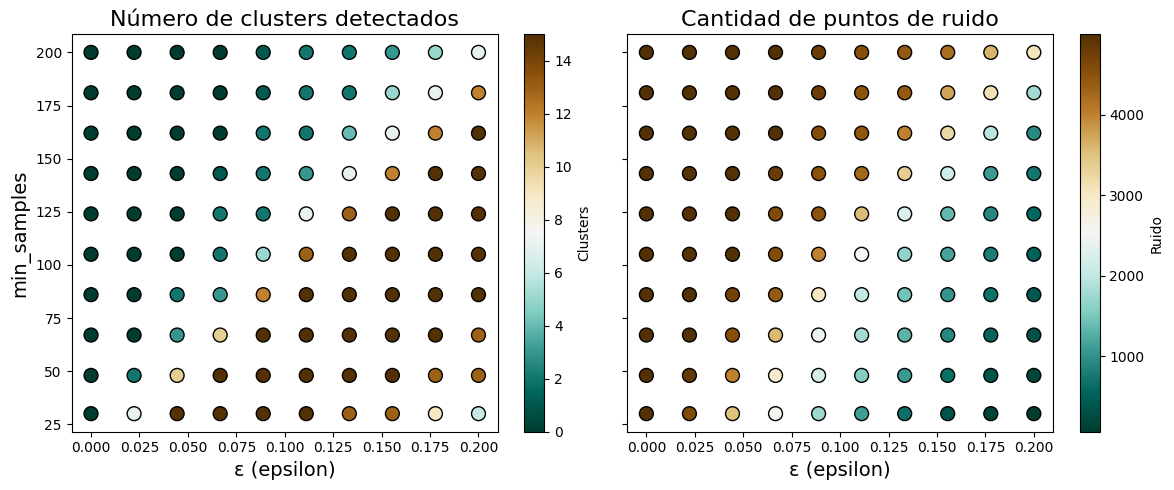

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sc1 = ax1.scatter(
    E_cpu, M_cpu,
    c=clusters.flatten(),
    cmap="BrBG_r",
    s=100,
    edgecolors="k"
)
ax1.set_title("Número de clusters detectados", fontsize=16)
ax1.set_xlabel("ε (epsilon)", fontsize=14)
ax1.set_ylabel("min_samples", fontsize=14)  
fig.colorbar(sc1, ax=ax1, label="Clusters")

sc2 = ax2.scatter(
    E_cpu, M_cpu,
    c=noise.flatten(),
    cmap="BrBG_r", #RdBu_r
    s=100,
    edgecolors="k"
)
ax2.set_title("Cantidad de puntos de ruido", fontsize=16)
ax2.set_xlabel("ε (epsilon)", fontsize=14)
fig.colorbar(sc2, ax=ax2, label="Ruido")

plt.tight_layout()
plt.show()

In [ ]:
X_cpu = clustering_df.values.astype(float)
X = cp.array(X_cpu)
mean = X.mean(axis=0)
std  = X.std(axis=0)
Xn = (X - mean) / std

Xn_cpu = cp.asnumpy(Xn)

eps_list     = np.linspace(0.0, 0.25, 40)    # 40 valores de eps
min_pts_list = np.linspace(30, 200, 40, dtype=int)  # 40 valores de min_samples

clusters = np.zeros((min_pts_list.size, eps_list.size), dtype=int)
noise    = np.zeros_like(clusters)

for i, min_pts in enumerate(min_pts_list):
    for j, eps in enumerate(eps_list):
        db = DBSCAN(eps=eps, min_samples=min_pts)
        labels = db.fit_predict(Xn_cpu)
        
        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})
        n_noise    = int((labels == -1).sum())
        
        clusters[i, j] = n_clusters
        noise[i, j]    = n_noise

E_cpu = np.repeat(eps_list[np.newaxis, :], min_pts_list.size, axis=0).flatten()
M_cpu = np.repeat(min_pts_list[:, np.newaxis], eps_list.size, axis=1).flatten()

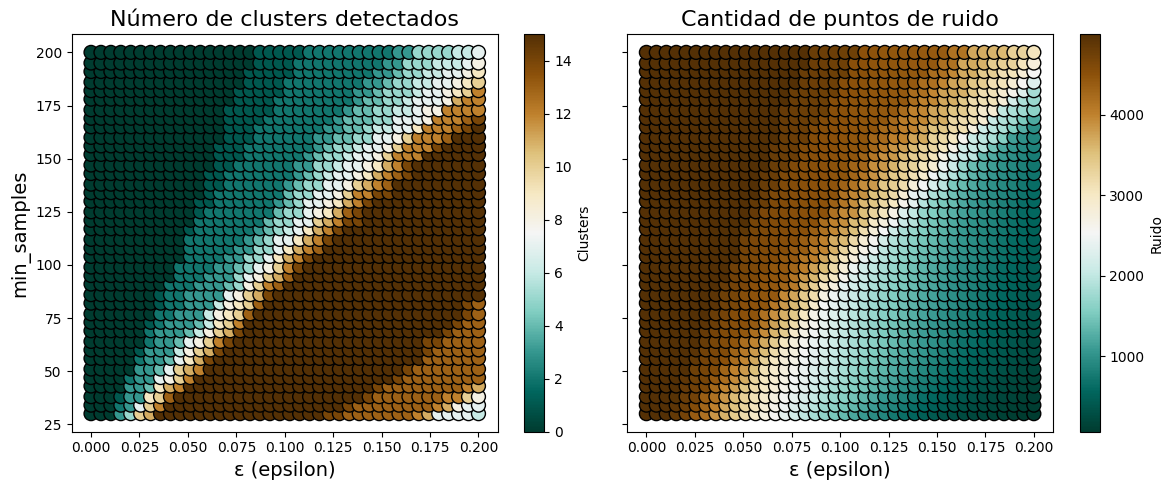

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sc1 = ax1.scatter(
    E_cpu, M_cpu,
    c=clusters.flatten(),
    cmap="BrBG_r",
    s=100,
    edgecolors="k"
)
ax1.set_title("Número de clusters detectados", fontsize=16)
ax1.set_xlabel("ε (epsilon)", fontsize=14)
ax1.set_ylabel("min_samples", fontsize=14)  
fig.colorbar(sc1, ax=ax1, label="Clusters")

sc2 = ax2.scatter(
    E_cpu, M_cpu,
    c=noise.flatten(),
    cmap="BrBG_r", #RdBu_r
    s=100,
    edgecolors="k"
)
ax2.set_title("Cantidad de puntos de ruido", fontsize=16)
ax2.set_xlabel("ε (epsilon)", fontsize=14)
fig.colorbar(sc2, ax=ax2, label="Ruido")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

def penalized_silhouette(X, labels, alpha=1.0, lambd=0.0):
    """
    Calcula silhouette penalizada:
      silhouette * (1 - noise_frac)^alpha  -  lambd * noise_frac
    """
    N = len(labels)
    noise_mask = (labels == -1)
    noise_frac = noise_mask.sum() / N
    
    # Si queda menos de 2 clusters, silhouette_score falla: devolvemos -1
    unique_labels = set(labels) - {-1}
    if len(unique_labels) < 2:
        return -1.0
    
    # Computar silhouette solo en non-noise
    sil = silhouette_score(X[~noise_mask], labels[~noise_mask])
    
    return sil * (1 - noise_frac)**alpha - lambd * noise_frac


# clusters y noise ya están calculados en el grid search:
best_score = -np.inf
best_params = None

for i, min_pts in enumerate(min_pts_list):
    for j, eps in enumerate(eps_list):
        db = DBSCAN(eps=eps, min_samples=min_pts)
        labels = db.fit_predict(Xn_cpu)
        
        score = penalized_silhouette(
            Xn_cpu, labels,
            alpha=1.0,    # penalización lineal
            lambd=0.5     # peso extra al ruido
        )
        
        if score > best_score:
            best_score  = score
            best_params = (eps, min_pts, db.n_clusters_, int((labels==-1).sum()))

print(f"Mejor combinación: ε={best_params[0]:.4f}, "
      f"min_samples={best_params[1]} → "
      f"{best_params[2]} clusters, {best_params[3]} ruido, score={best_score:.3f}")


Mejor combinación: ε=0.2308, min_samples=130 → 15 clusters, 266 ruido, score=0.597


##### Elección de una combinación de ε y K

In [ ]:
eps_new       = 0.2308
min_samples   = 130

In [ ]:
Xn_cpu = cp.asnumpy(Xn)

db = DBSCAN(eps=eps_new, min_samples=min_samples)
labels_new = db.fit_predict(Xn_cpu) 

n_clusters = db.n_clusters_
n_noise    = int((labels_new == -1).sum())
total_pts  = labels_new.size
noise_pct  = 100 * n_noise / total_pts

print(
    f"DBSCAN ε={eps_new}, min_samples={min_samples} → "
    f"{n_clusters} clusters, {n_noise} puntos de ruido "
    f"({noise_pct:.2f}% del total)"
)

##### Gráfico de los datos

DBSCAN ε=0.2308, min_samples=130 → 15 clusters, 266 puntos de ruido (5.32% del total)


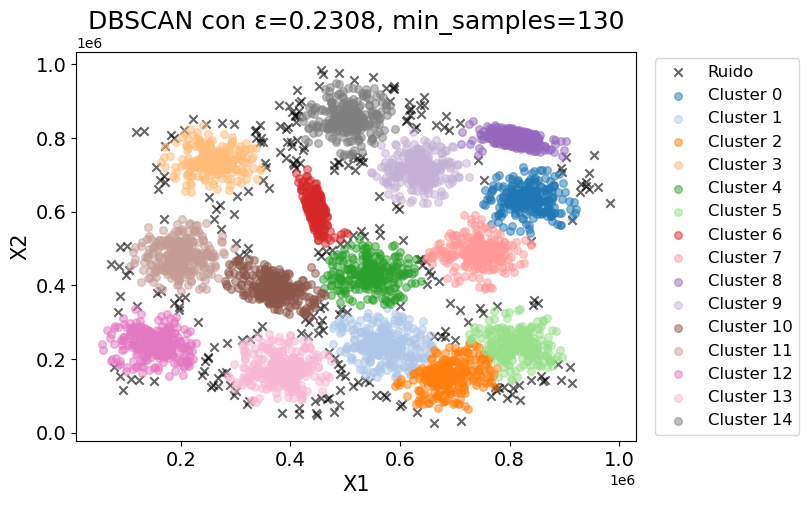

In [ ]:
from src.plot import plot_DBSCAN

plot_DBSCAN(X_cpu, labels, min_samples, eps_new)

## `2.` **Reducción de dimensionalidad**

##### Cargar los datos


In [70]:
import numpy as np

In [245]:
MNIST_path = "data/MNIST_dataset.csv"

MNIST_df = pd.read_csv(MNIST_path)
y = MNIST_df.iloc[:, 0].values.astype(int)
X_np = MNIST_df.iloc[:, 1:].values.astype(float) 
X = cp.array(X_np)


### `a.` **PCA**

In [246]:
from src.models import PCA

In [257]:
components = [5, 10, 15, 26, 43, 59, 87, 140, 200, 400, 784]
mse_list = []

for k in components:
    pca = PCA(n_components=k).fit(X)
    X_proj = pca.transform(X)
    X_rec = pca.inverse_transform(X_proj)

    mse_k = cp.mean((X - X_rec) ** 2)
    mse_list.append(mse_k.get())  # traemos a CPU para almacenar
    print(f"PCA k={k}: MSE = {mse_list[-1]:.4f}")

PCA k=5: MSE = 2873.9210
PCA k=10: MSE = 2158.8887
PCA k=15: MSE = 1743.1503
PCA k=26: MSE = 1200.8622
PCA k=43: MSE = 774.5836
PCA k=59: MSE = 564.2727
PCA k=87: MSE = 364.2128
PCA k=140: MSE = 198.5566
PCA k=200: MSE = 114.9304
PCA k=400: MSE = 14.4733
PCA k=784: MSE = 0.0000


##### Gráfico de cómo varía el error cuadrático medio de reconstrucción sobre el conjunto de datos en función de la cantidad de componentes principales utilizadas

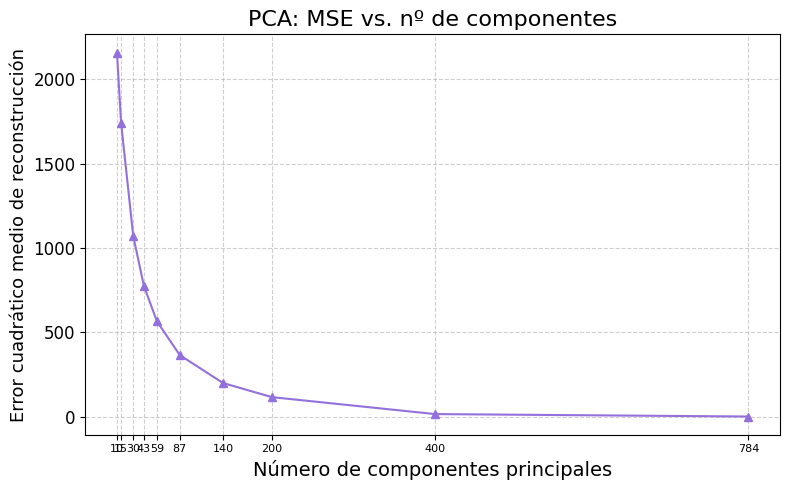

In [ ]:
from src.plot import plot_mse_vs_components

plot_mse_vs_components(components, mse_list)

### `b.` Selección de **componentes principales**

In [247]:
pca_full = PCA(n_components=X.shape[1]).fit(X)

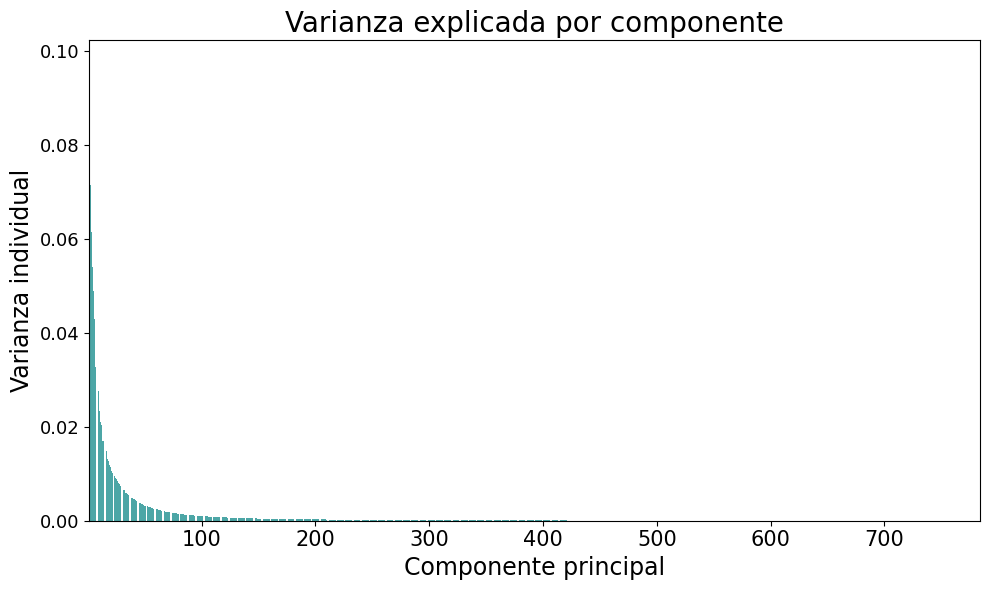

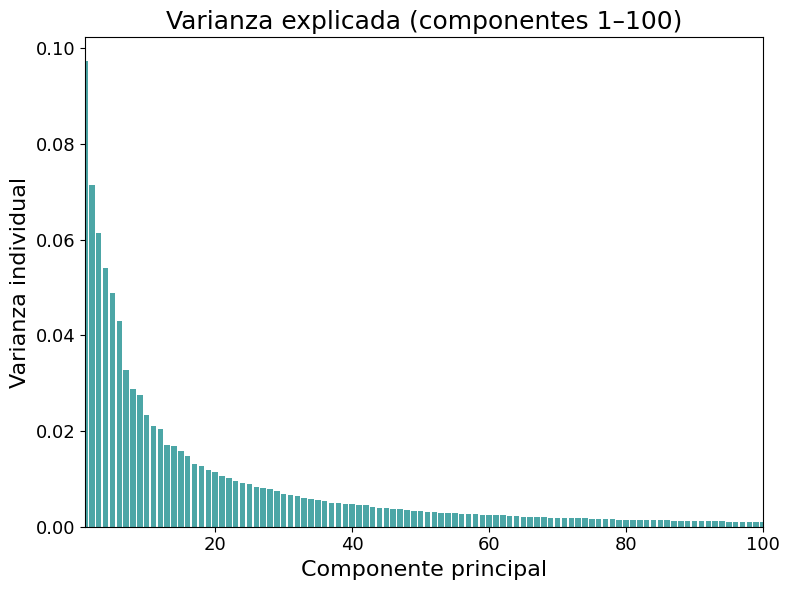

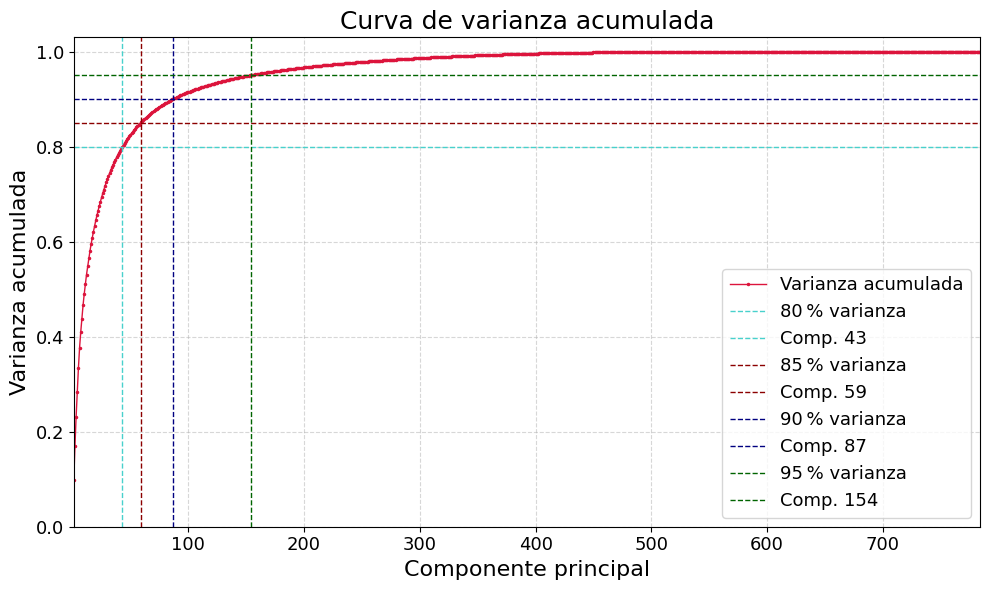

In [244]:
pca_full.plot_explained_variance()

##### Elegir k según varianza acumulada (90%)

In [249]:
cum_var = pca_full.cummulative_variance()
k_90 = int(cp.argmax(cum_var >= 0.90) + 1)
print(f"Componentes necesarias para 90% de varianza: {k_90}")

Componentes necesarias para 90% de varianza: 87


In [189]:
pca_k = PCA(n_components=k_90).fit(X)
X_proj = pca_k.transform(X)
X_rec = pca_k.inverse_transform(X_proj)

##### Gráfico de las imagenes de los digitos originales y reconstruidos para las primeras 10 muestras del dataset con 87 cantidad de componentes

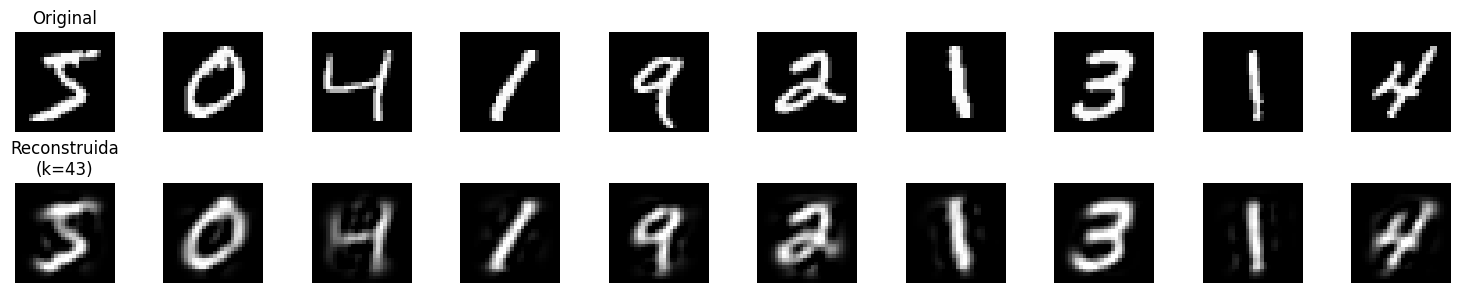

In [ ]:
from src.plot import plot_PCA
    
plot_PCA(X, X_rec, k_90)

80% varianza → k = 43
85% varianza → k = 59
90% varianza → k = 87


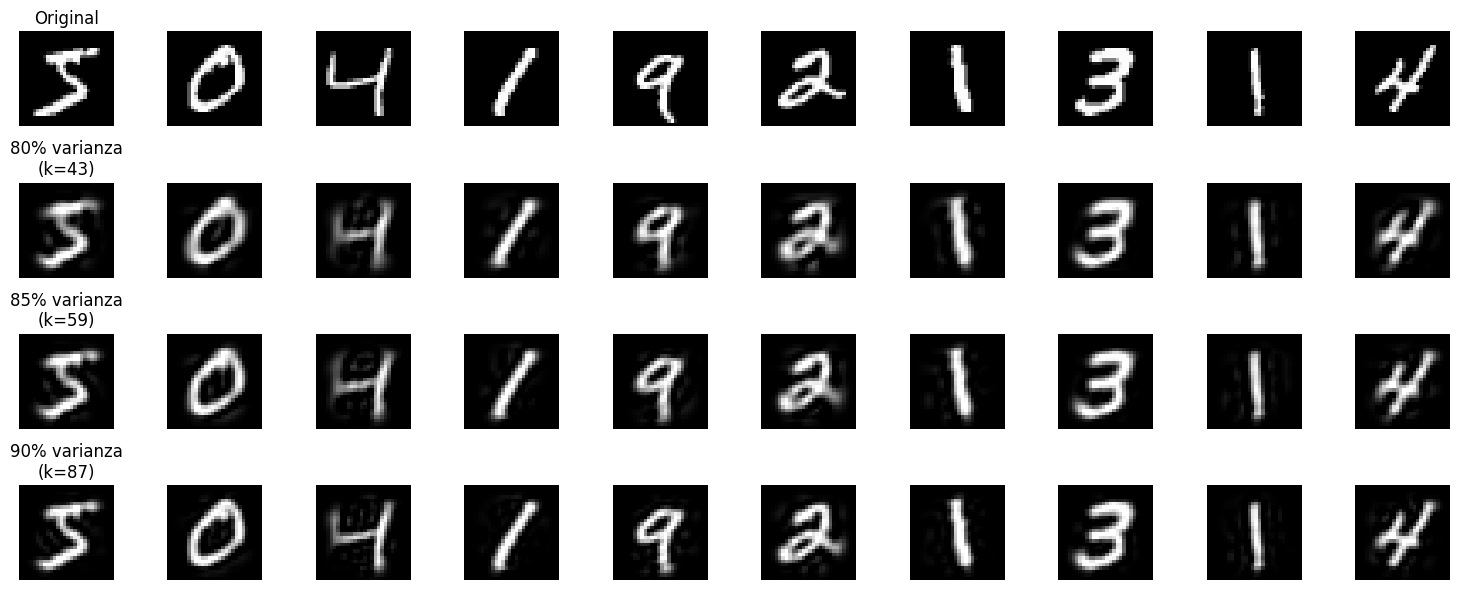

In [ ]:
from src.plot import plot_PCA_different_variances
    
plot_PCA_different_variances(X, pca_full, n_show=10)


### `c.` Modelo de Autoencoder Variacional (**VAE**) usando PyTorch

##### División en entrenamiento y validación

In [ ]:
import torch
from torch import from_numpy
from torch.utils.data import TensorDataset, DataLoader, Subset

In [81]:
from src.models import VAE

In [ ]:
X_np_vae = (MNIST_df.iloc[:, 1:].values / 255.0).astype(np.float32)
y_np_vae = MNIST_df.iloc[:, 0].values.astype(int)

dataset_full = TensorDataset(from_numpy(X_np_vae), from_numpy(y_np_vae))

# Separar 10 imágenes para TEST
np.random.seed(42)
n_total = len(dataset_full)
test_size = 10

all_indices = np.arange(n_total)
test_indices = np.random.choice(all_indices, size=test_size, replace=False)

remaining_indices = np.setdiff1d(all_indices, test_indices)

test_ds     = Subset(dataset_full, test_indices)      # las 10 de test
trainval_ds = Subset(dataset_full, remaining_indices)

##### Búsqueda de Hiperparámetros y Entrenamiento

In [ ]:
num_folds = 5
fold_size = len(trainval_ds) // num_folds
indices_trainval = np.arange(len(trainval_ds)) 

latent_list = [2, 5, 10, 20, 50]
lr_list     = [1e-2, 1e-3, 1e-4]
hidden_list = [200, 400, 800]

best_cfg = None
best_cv_loss = float('inf')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from src.utils import cv
best_cfg, best_cv_loss = cv(latent_list, lr_list, hidden_list, num_folds, fold_size, indices_trainval, trainval_ds, device)
print("Mejor configuración encontrada:", best_cfg, "con val_loss=", best_cv_loss)

best_latent, best_hidden, best_lr = best_cfg

# modelo final con la mejor configuración
trainval_loader = DataLoader(trainval_ds, batch_size=128, shuffle=True)
val_loader_full = DataLoader(trainval_ds, batch_size=128, shuffle=False)

vae = VAE(input_dim=784, hidden_dim=best_hidden, latent_dim=best_latent)
train_losses_full, val_losses_full = vae.fit(
    trainval_loader,
    val_loader_full,
    n_epochs=20,
    lr=best_lr,
    device=device
)
vae.plot_training_curves(train_losses_full, val_losses_full)


 5‑fold CV para búsqueda de hiperparámetros
Epoch 01 — Train loss: 176.2528, Val loss: 165.4665
Epoch 02 — Train loss: 162.4742, Val loss: 162.3664
Epoch 03 — Train loss: 159.3983, Val loss: 159.8727
Epoch 04 — Train loss: 157.6865, Val loss: 157.5479
Epoch 05 — Train loss: 156.6263, Val loss: 157.1868
Epoch 06 — Train loss: 155.8302, Val loss: 157.0426
Epoch 07 — Train loss: 155.2950, Val loss: 156.7231
Epoch 01 — Train loss: 175.8360, Val loss: 166.3738
Epoch 02 — Train loss: 162.1517, Val loss: 162.4045
Epoch 03 — Train loss: 159.3525, Val loss: 159.9402
Epoch 04 — Train loss: 157.7097, Val loss: 158.1934
Epoch 05 — Train loss: 156.3531, Val loss: 158.0062
Epoch 06 — Train loss: 155.5191, Val loss: 157.8104
Epoch 07 — Train loss: 154.7327, Val loss: 157.7389
Epoch 01 — Train loss: 175.0908, Val loss: 165.4538
Epoch 02 — Train loss: 162.8767, Val loss: 162.5859
Epoch 03 — Train loss: 160.1520, Val loss: 159.9061
Epoch 04 — Train loss: 158.2218, Val loss: 159.1305
Epoch 05 — Train lo

In [263]:
trainval_loader = DataLoader(trainval_ds, batch_size=128, shuffle=True)
val_loader_full = DataLoader(trainval_ds, batch_size=128, shuffle=False)

vae = VAE(input_dim=784, hidden_dim=best_hidden, latent_dim=best_latent)
train_losses_full, val_losses_full = vae.fit(
    trainval_loader,
    val_loader_full,
    n_epochs=20,
    lr=best_lr,
    device=device
)

Epoch 01 — Train loss: 148.8439, Val loss: 118.8355
Epoch 02 — Train loss: 113.7889, Val loss: 110.6970
Epoch 03 — Train loss: 109.4803, Val loss: 108.3341
Epoch 04 — Train loss: 107.5435, Val loss: 106.6376
Epoch 05 — Train loss: 106.4368, Val loss: 105.7241
Epoch 06 — Train loss: 105.5790, Val loss: 104.9503
Epoch 07 — Train loss: 104.9657, Val loss: 104.4437
Epoch 08 — Train loss: 104.5007, Val loss: 104.0184
Epoch 09 — Train loss: 104.1174, Val loss: 103.7026
Epoch 10 — Train loss: 103.7547, Val loss: 103.4476
Epoch 11 — Train loss: 103.4262, Val loss: 103.1508
Epoch 12 — Train loss: 103.1570, Val loss: 102.8337
Epoch 13 — Train loss: 102.9323, Val loss: 102.6704
Epoch 14 — Train loss: 102.6765, Val loss: 102.4041
Epoch 15 — Train loss: 102.4861, Val loss: 102.0984
Epoch 16 — Train loss: 102.2994, Val loss: 102.0188
Epoch 17 — Train loss: 102.0940, Val loss: 101.8973
Epoch 18 — Train loss: 101.9273, Val loss: 101.6506
Epoch 19 — Train loss: 101.7739, Val loss: 101.6322
Epoch 20 — T

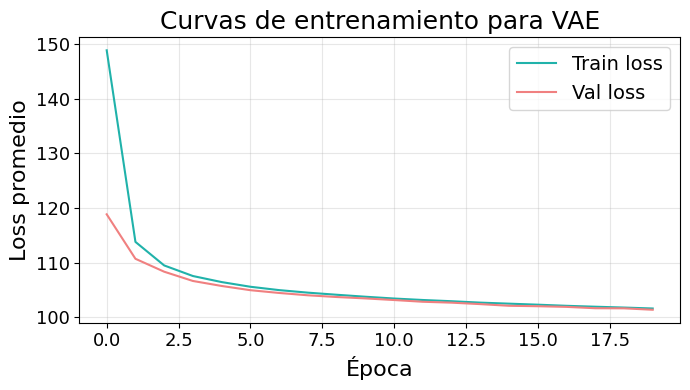

In [264]:
vae.plot_training_curves(train_losses_full, val_losses_full)

##### Comparación con PCA

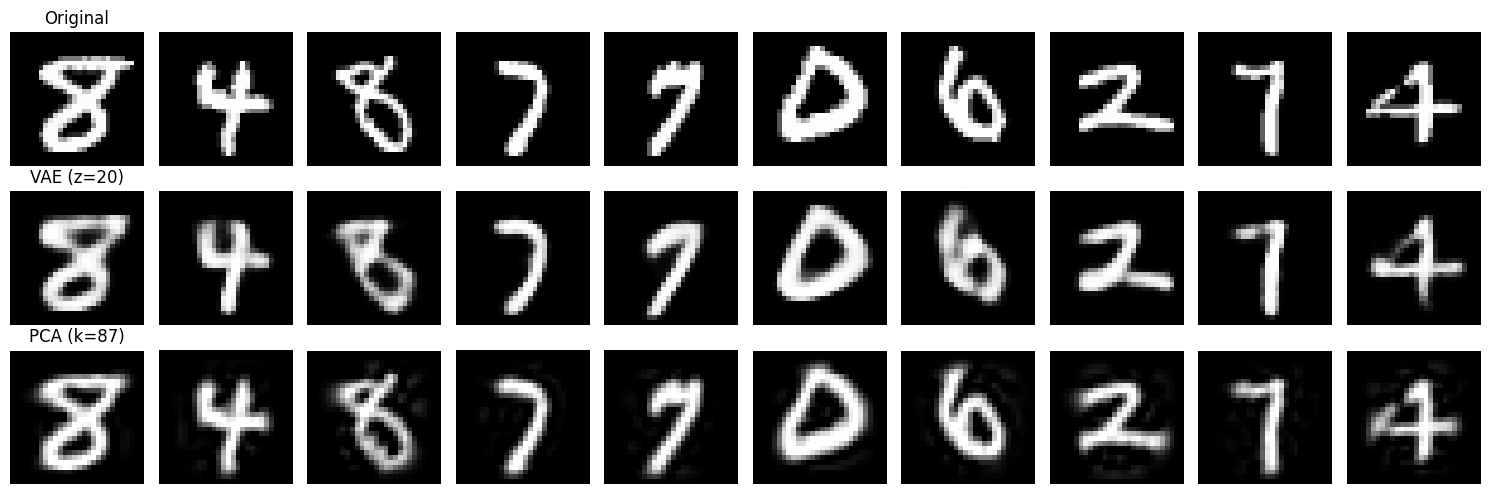

In [ ]:
vae.eval()
with torch.no_grad():
    # Sacamos las 10 imágenes de test en un único batch
    x_test_batch, y_test_batch = next(iter(DataLoader(test_ds, batch_size=test_size, shuffle=False)))
    x_test_batch = x_test_batch.to(device).float()

    x_rec_vae, mu, logvar = vae(x_test_batch)
    rec_vae_np = x_rec_vae.cpu().numpy()
    
    
pca_k = PCA(n_components=k_90).fit(X)

# Reconstruimos las 10 de test
x_test = cp.array(x_test_batch.cpu().numpy() * 255.0)
x_proj_pca = pca_k.transform(x_test)
x_rec_pca  = pca_k.inverse_transform(x_proj_pca)
rec_pca_np = x_rec_pca.get() / 255.0 

from src.plot import plot_comparison_og_VAE_PCA

plot_comparison_og_VAE_PCA(x_test_batch, rec_vae_np, rec_pca_np, test_size, best_latent, k_90)